In [ ]:
# Upload file heart_disease.csv langsung ke Colab
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("UPLOAD DATASET")
print("="*60)
print("Silakan upload file 'heart_disease.csv'")
print("Klik tombol 'Choose Files' atau drag & drop file")

uploaded = files.upload()

# Cek file yang diupload
print("\n" + "="*60)
print("FILE YANG DIUPLOAD")
print("="*60)
for filename in uploaded.keys():
    print(f"✅ {filename} - berhasil diupload!")

# Cari file heart_disease.csv
dataset_file = None
for filename in uploaded.keys():
    if 'heart_disease' in filename.lower() or 'heart' in filename.lower():
        dataset_file = filename
        break

if dataset_file is None:
    print("\n❌ File heart_disease.csv tidak ditemukan!")
    print("Silakan upload ulang file yang benar.")
else:
    print(f"\n✅ Dataset ditemukan: {dataset_file}")

UPLOAD DATASET
Silakan upload file 'heart_disease.csv'
Klik tombol 'Choose Files' atau drag & drop file


Saving heart_disease.csv to heart_disease.csv

FILE YANG DIUPLOAD
✅ heart_disease.csv - berhasil diupload!

✅ Dataset ditemukan: heart_disease.csv


In [ ]:
# Load dataset
if dataset_file is not None:
    df = pd.read_csv(dataset_file)
    print("="*60)
    print("DATASET BERHASIL DIMUAT")
    print("="*60)

    # Tampilkan 5 data pertama
    print("\n5 DATA PERTAMA:")
    print(df.head())

    # Informasi dataset
    print("\n" + "="*60)
    print("INFORMASI DATASET")
    print("="*60)
    print(df.info())

    # Statistik deskriptif (hanya untuk kolom numerik)
    print("\n" + "="*60)
    print("STATISTIK DESKRIPTIF")
    print("="*60)
    print(df.describe())

    # Cek missing values
    print("\n" + "="*60)
    print("MISSING VALUES")
    print("="*60)
    print(df.isnull().sum())

    # ============================================================
    # ENCODING KOLOM KATEGORIK
    # ============================================================
    print("\n" + "="*60)
    print("ENCODING DATA KATEGORIK")
    print("="*60)

    from sklearn.preprocessing import LabelEncoder

    # Cek kolom dengan tipe object
    for col in df.columns:
        if df[col].dtype == 'object':
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])
            print(f"✅ Kolom '{col}' telah di-encode")

    # Cek tipe data setelah encoding
    print("\nTipe data setelah encoding:")
    print(df.dtypes)

else:
    print("❌ Dataset tidak tersedia!")

DATASET BERHASIL DIMUAT

5 DATA PERTAMA:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

   ca        thal  target  
0   0       fixed       0  
1   3      normal       1  
2   2  reversible       0  
3   0      normal       0  
4   0      normal       0  

INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-n

In [ ]:
# Import library untuk machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import joblib

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


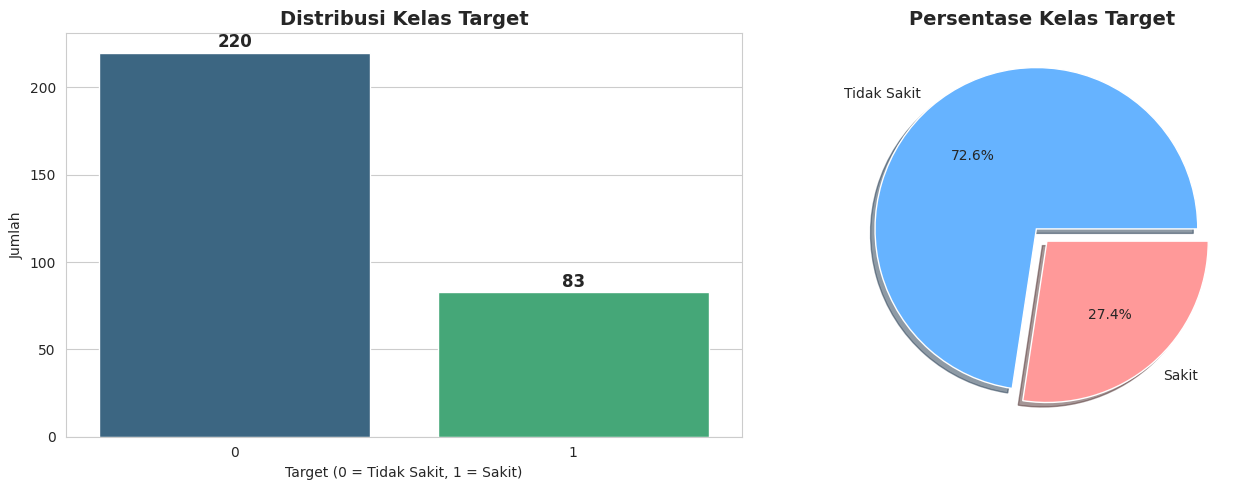

In [ ]:
# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Distribusi Target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sns.countplot(x='target', data=df, palette='viridis', ax=axes[0])
axes[0].set_title('Distribusi Kelas Target', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Target (0 = Tidak Sakit, 1 = Sakit)')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(df['target'].value_counts().values):
    axes[0].text(i, v+3, str(v), ha='center', fontsize=12, fontweight='bold')

# Pie chart
df['target'].value_counts().plot.pie(
    autopct='%1.1f%%',
    labels=['Tidak Sakit', 'Sakit'],
    colors=['#66b3ff', '#ff9999'],
    explode=(0.05, 0.05),
    shadow=True,
    ax=axes[1]
)
axes[1].set_title('Persentase Kelas Target', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

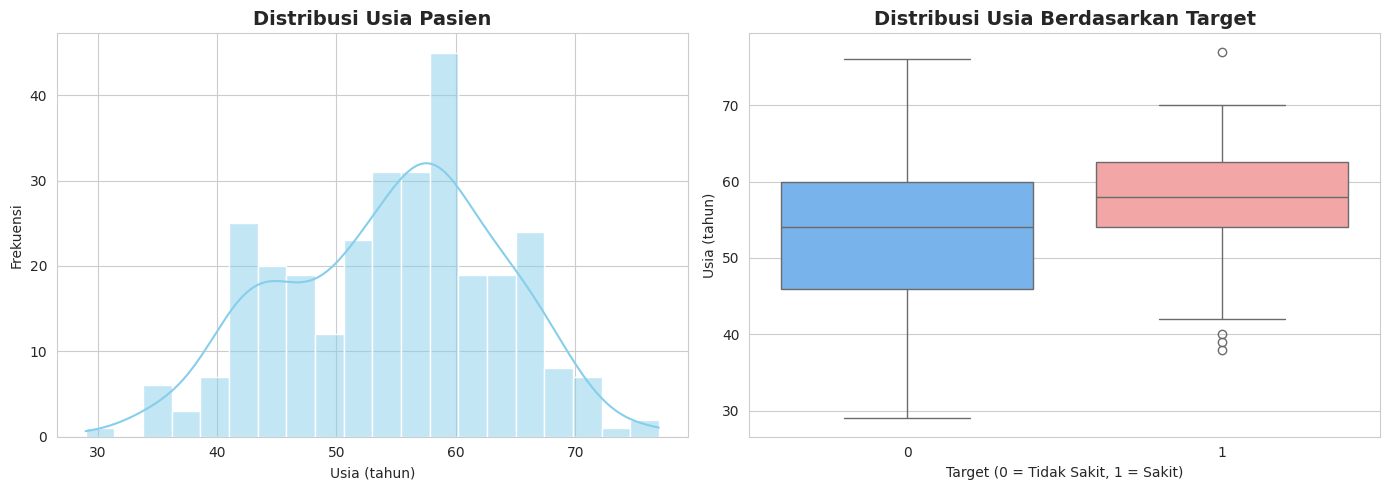

In [ ]:
# 2. Distribusi Usia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram usia
sns.histplot(data=df, x='age', bins=20, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribusi Usia Pasien', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Usia (tahun)')
axes[0].set_ylabel('Frekuensi')

# Boxplot usia berdasarkan target
sns.boxplot(x='target', y='age', data=df, palette=['#66b3ff', '#ff9999'], ax=axes[1])
axes[1].set_title('Distribusi Usia Berdasarkan Target', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Target (0 = Tidak Sakit, 1 = Sakit)')
axes[1].set_ylabel('Usia (tahun)')

plt.tight_layout()
plt.show()

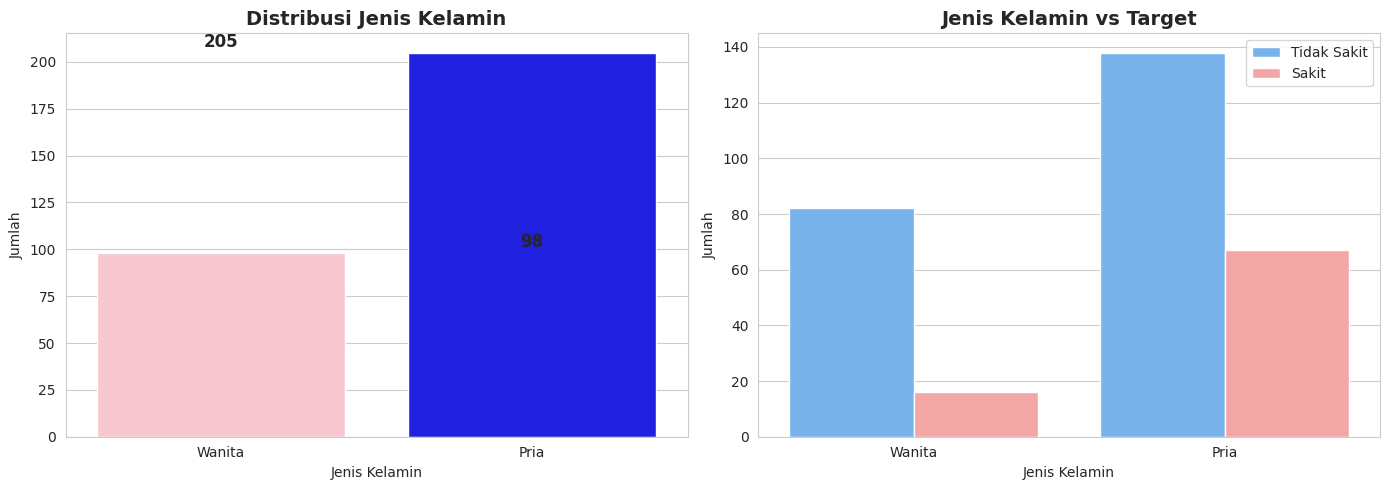

In [ ]:
# 3. Distribusi Jenis Kelamin
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Countplot sex
sns.countplot(x='sex', data=df, palette=['pink', 'blue'], ax=axes[0])
axes[0].set_title('Distribusi Jenis Kelamin', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['Wanita', 'Pria'])
axes[0].set_xlabel('Jenis Kelamin')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(df['sex'].value_counts().values):
    axes[0].text(i, v+3, str(v), ha='center', fontsize=12, fontweight='bold')

# Sex vs Target
sns.countplot(x='sex', hue='target', data=df, palette=['#66b3ff', '#ff9999'], ax=axes[1])
axes[1].set_title('Jenis Kelamin vs Target', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Wanita', 'Pria'])
axes[1].set_xlabel('Jenis Kelamin')
axes[1].set_ylabel('Jumlah')
axes[1].legend(['Tidak Sakit', 'Sakit'])

plt.tight_layout()
plt.show()

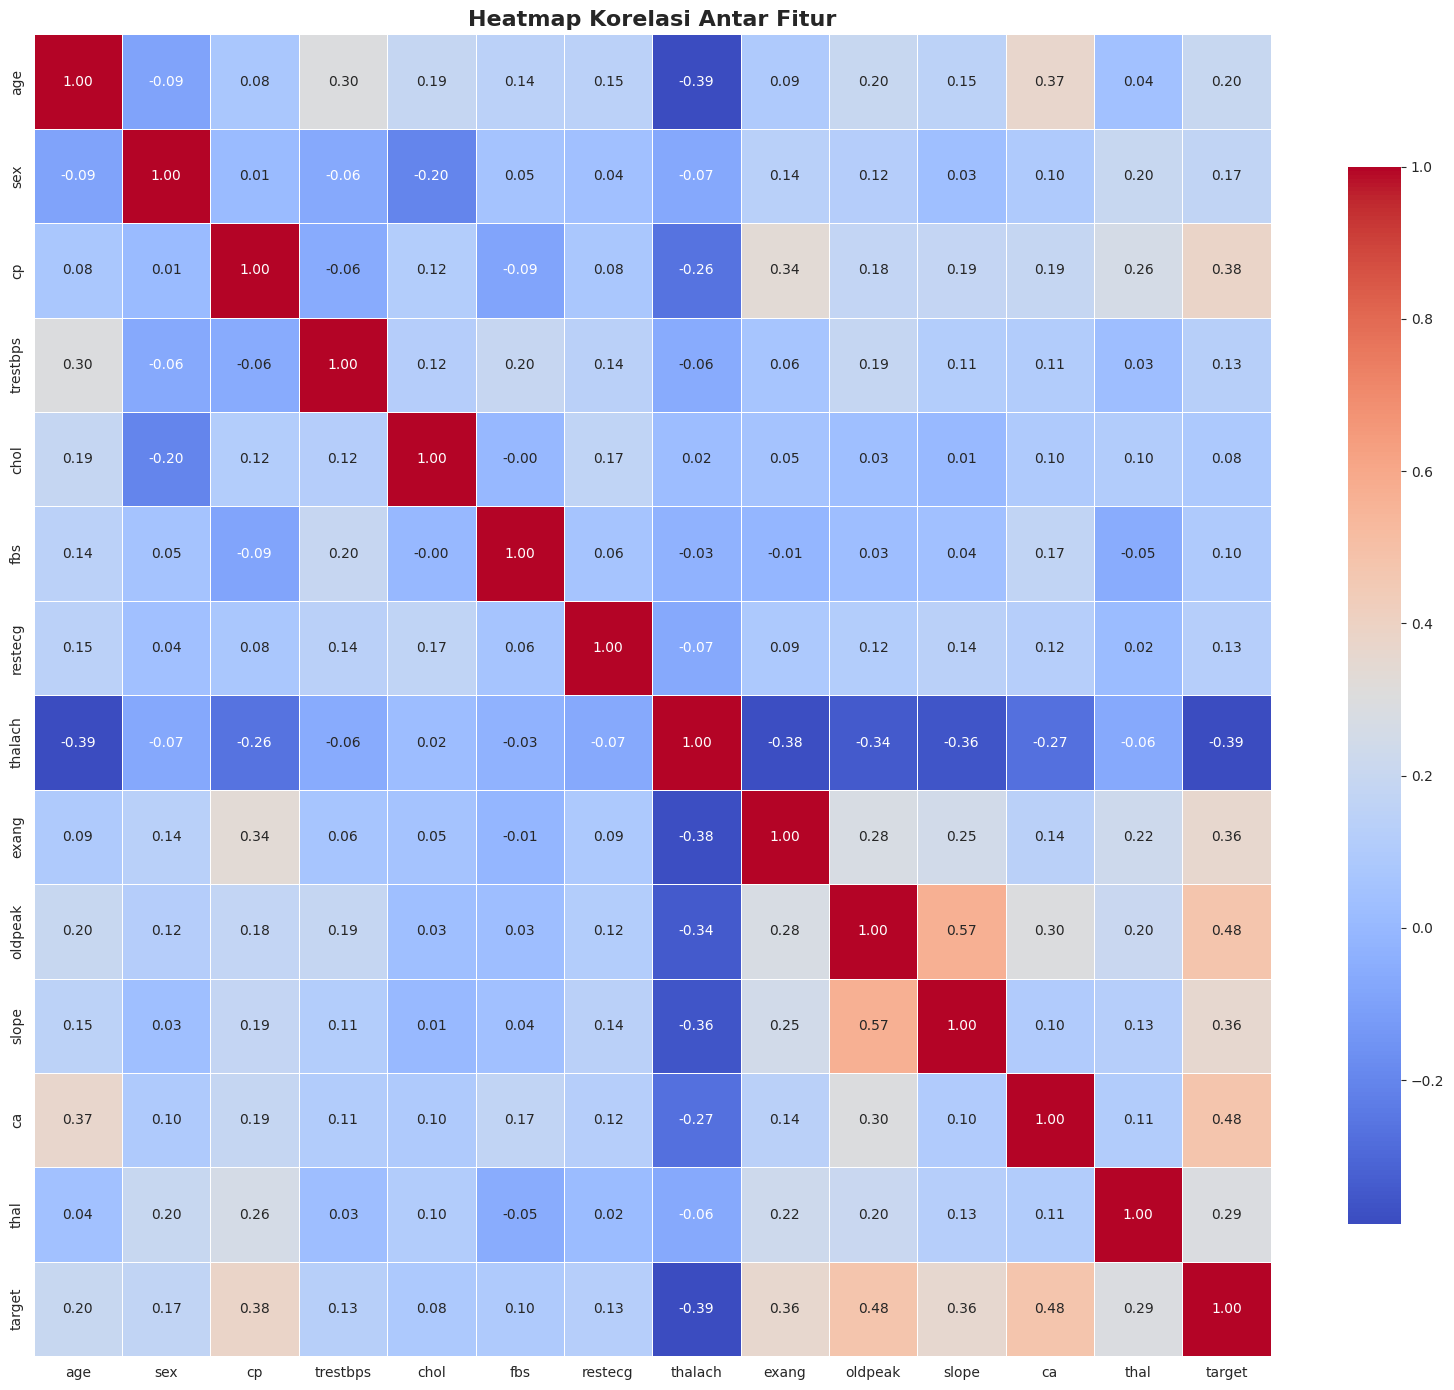

✅ Heatmap korelasi berhasil dibuat!


In [ ]:
# 4. Heatmap Korelasi
# Pastikan semua kolom numerik
plt.figure(figsize=(16, 14))

# Hanya pilih kolom numerik untuk korelasi
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Heatmap Korelasi Antar Fitur', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Heatmap korelasi berhasil dibuat!")

KORELASI FITUR DENGAN TARGET
target          : 1.0000
ca              : 0.4766
oldpeak         : 0.4753
cp              : 0.3817
exang           : 0.3610
slope           : 0.3596
thal            : 0.2940
age             : 0.1987
sex             : 0.1716
trestbps        : 0.1294
restecg         : 0.1262
fbs             : 0.0973
chol            : 0.0833
thalach         : -0.3865


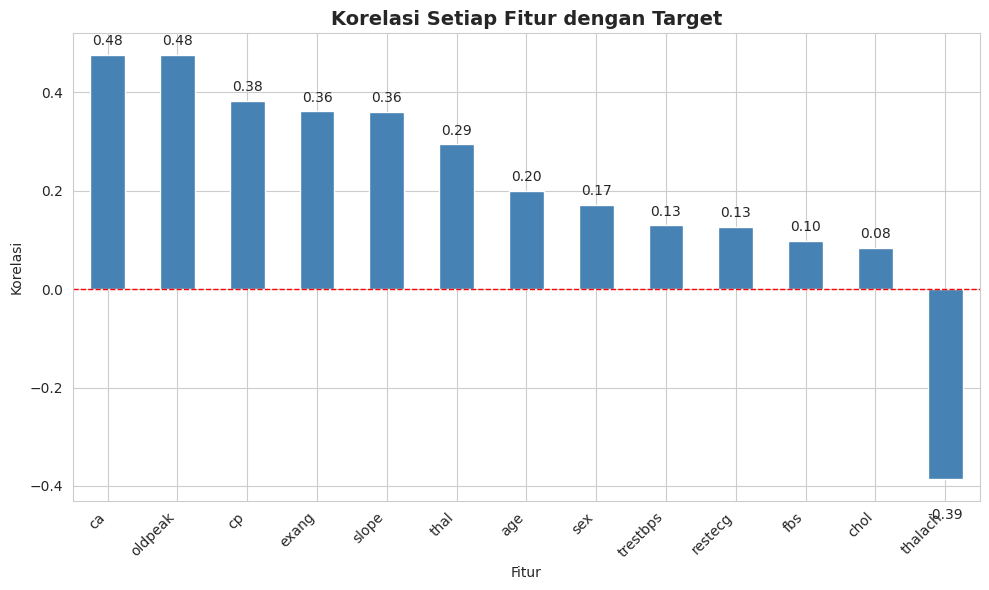

In [ ]:
# 5. Fitur dengan korelasi tertinggi terhadap target
corr_target = corr_matrix['target'].sort_values(ascending=False)

print("="*60)
print("KORELASI FITUR DENGAN TARGET")
print("="*60)
for feature, corr in corr_target.items():
    print(f"{feature:15} : {corr:.4f}")

# Visualisasi korelasi
plt.figure(figsize=(10, 6))
corr_target.drop('target').plot(kind='bar', color='steelblue')
plt.title('Korelasi Setiap Fitur dengan Target', fontsize=14, fontweight='bold')
plt.xlabel('Fitur')
plt.ylabel('Korelasi')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
for i, v in enumerate(corr_target.drop('target')):
    plt.text(i, v+0.02 if v>0 else v-0.08, f'{v:.2f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# 6. Cek keseimbangan kelas
class_counts = df['target'].value_counts()
total = len(df)

print("="*60)
print("ANALISIS KESEIMBANGAN KELAS")
print("="*60)
print(f"Kelas 0 (Tidak Sakit): {class_counts[0]} ({class_counts[0]/total*100:.1f}%)")
print(f"Kelas 1 (Sakit)     : {class_counts[1]} ({class_counts[1]/total*100:.1f}%)")

# Cek imbalance
ratio = abs(class_counts[0] - class_counts[1]) / total
if ratio < 0.1:
    print(f"\n✅ Data relatif seimbang (rasio perbedaan: {ratio:.3f})")
else:
    print(f"\n⚠️  Data tidak seimbang (rasio perbedaan: {ratio:.3f})")
    print("   Perlu pertimbangan untuk oversampling/undersampling")

ANALISIS KESEIMBANGAN KELAS
Kelas 0 (Tidak Sakit): 220 (72.6%)
Kelas 1 (Sakit)     : 83 (27.4%)

⚠️  Data tidak seimbang (rasio perbedaan: 0.452)
   Perlu pertimbangan untuk oversampling/undersampling


In [ ]:
# 7. Pembersihan data
print("="*60)
print("PEMBERSIHAN DATA")
print("="*60)

# Cek duplikat
duplicates = df.duplicated().sum()
print(f"Jumlah data duplikat: {duplicates}")

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("✅ Data duplikat dihapus")
else:
    print("✅ Tidak ada data duplikat")

# Cek missing values
missing = df.isnull().sum().sum()
print(f"Jumlah missing values: {missing}")

if missing > 0:
    df.fillna(df.median(), inplace=True)
    print("✅ Missing values diisi dengan median")
else:
    print("✅ Tidak ada missing values")

# 8. Pisahkan fitur dan target
X = df.drop('target', axis=1)
y = df['target']

print(f"\nJumlah fitur: {X.shape[1]}")
print(f"Jumlah sampel: {X.shape[0]}")
print(f"Jumlah target: {len(y.unique())} kelas")

# 9. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nData training : {X_train.shape[0]} sampel")
print(f"Data testing  : {X_test.shape[0]} sampel")

# 10. Standardisasi
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Standardisasi selesai")

PEMBERSIHAN DATA
Jumlah data duplikat: 0
✅ Tidak ada data duplikat
Jumlah missing values: 0
✅ Tidak ada missing values

Jumlah fitur: 13
Jumlah sampel: 303
Jumlah target: 2 kelas

Data training : 242 sampel
Data testing  : 61 sampel

✅ Standardisasi selesai


In [ ]:
# 11. Decision Tree
print("="*60)
print("MODEL 1: DECISION TREE")
print("="*60)

# Inisialisasi dan training
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5
)
dt_model.fit(X_train_scaled, y_train)

# Prediksi
y_pred_dt = dt_model.predict(X_test_scaled)

# Evaluasi
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Akurasi Decision Tree : {accuracy_dt:.4f} ({accuracy_dt*100:.2f}%)")

# Feature importance
feature_importance = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

MODEL 1: DECISION TREE
Akurasi Decision Tree : 0.8033 (80.33%)

Feature Importance:
       Fitur  Importance
9    oldpeak    0.387765
2         cp    0.186561
8      exang    0.085182
7    thalach    0.068016
10     slope    0.068008
11        ca    0.051852
12      thal    0.047130
6    restecg    0.046768
1        sex    0.044405
4       chol    0.011905
3   trestbps    0.002407
0        age    0.000000
5        fbs    0.000000


MODEL 2: K-NEAREST NEIGHBOR (KNN)


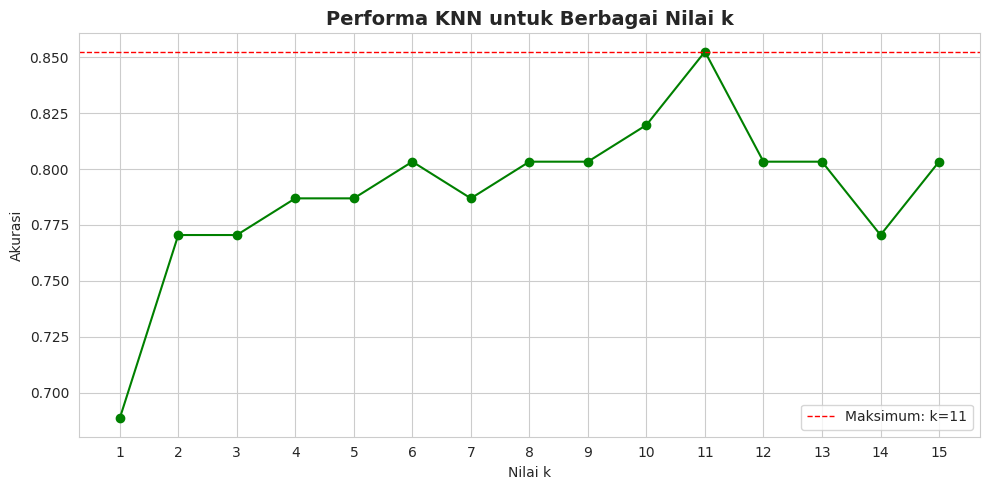

Nilai k optimal: 11
Akurasi KNN (k=11) : 0.8525 (85.25%)


In [ ]:
# 12. K-Nearest Neighbor
print("="*60)
print("MODEL 2: K-NEAREST NEIGHBOR (KNN)")
print("="*60)

# Cari nilai k optimal (1-15)
k_values = range(1, 16)
k_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    score = knn.score(X_test_scaled, y_test)
    k_scores.append(score)

# Visualisasi performa tiap k
plt.figure(figsize=(10, 5))
plt.plot(k_values, k_scores, marker='o', linestyle='-', color='green')
plt.title('Performa KNN untuk Berbagai Nilai k', fontsize=14, fontweight='bold')
plt.xlabel('Nilai k')
plt.ylabel('Akurasi')
plt.xticks(k_values)
plt.axhline(y=max(k_scores), color='red', linestyle='--', linewidth=1,
            label=f'Maksimum: k={k_values[k_scores.index(max(k_scores))]}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Gunakan k terbaik
best_k = k_values[k_scores.index(max(k_scores))]
print(f"Nilai k optimal: {best_k}")

# Training dengan k optimal
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"Akurasi KNN (k={best_k}) : {accuracy_knn:.4f} ({accuracy_knn*100:.2f}%)")

PERBANDINGAN AKURASI MODEL
           Model   Akurasi  Akurasi %
0  Decision Tree  0.803279  80.327869
1            KNN  0.852459  85.245902


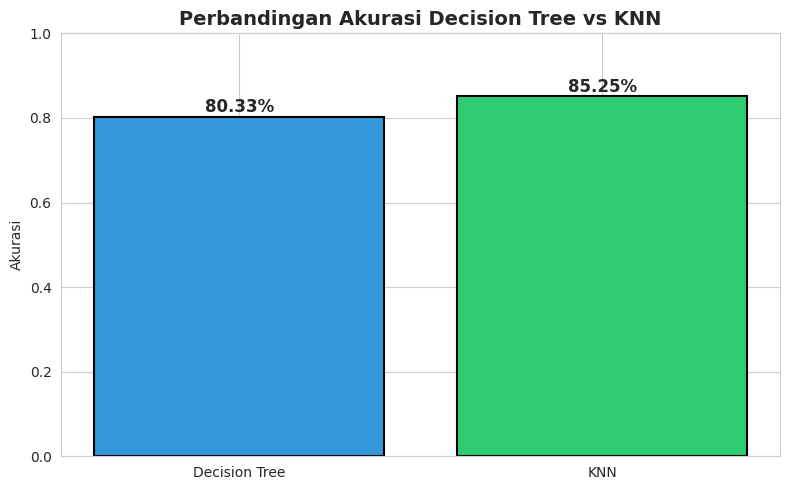


🏆 Model Terbaik: KNN dengan akurasi 85.25%


In [ ]:
# 13. Perbandingan akurasi
print("="*60)
print("PERBANDINGAN AKURASI MODEL")
print("="*60)

comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'KNN'],
    'Akurasi': [accuracy_dt, accuracy_knn]
})
comparison['Akurasi %'] = comparison['Akurasi'] * 100

print(comparison)

# Visualisasi perbandingan
plt.figure(figsize=(8, 5))
bars = plt.bar(comparison['Model'], comparison['Akurasi'],
               color=['#3498db', '#2ecc71'], edgecolor='black', linewidth=1.5)
plt.title('Perbandingan Akurasi Decision Tree vs KNN', fontsize=14, fontweight='bold')
plt.ylabel('Akurasi')
plt.ylim(0, 1)

for bar, acc in zip(bars, comparison['Akurasi']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc*100:.2f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Model terbaik
best_model = comparison.loc[comparison['Akurasi'].idxmax(), 'Model']
best_accuracy = comparison['Akurasi'].max()
print(f"\n🏆 Model Terbaik: {best_model} dengan akurasi {best_accuracy*100:.2f}%")

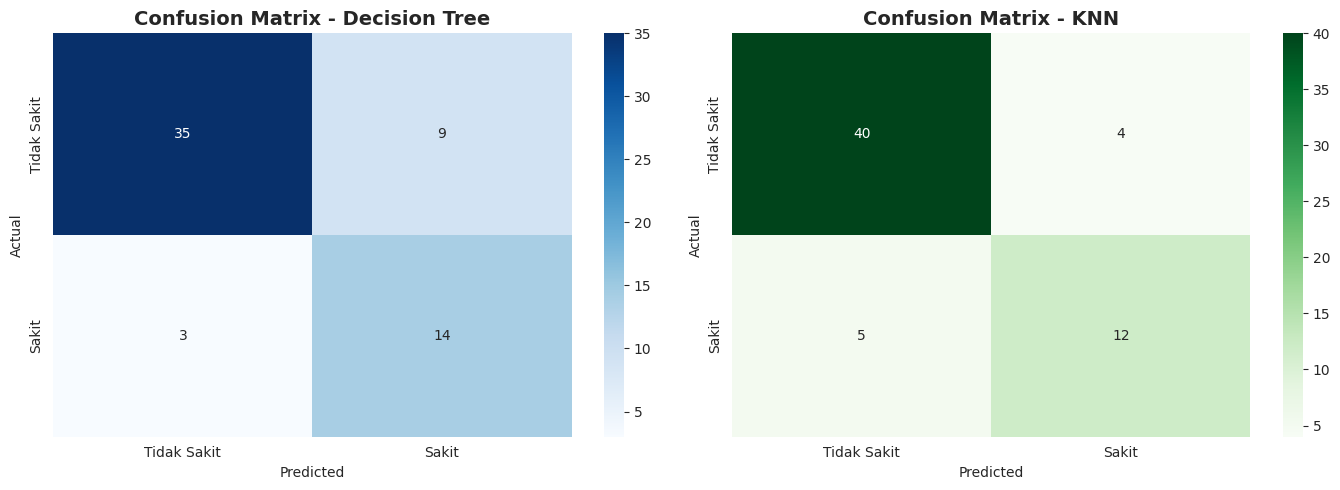

In [ ]:
# 14. Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Sakit', 'Sakit'],
            yticklabels=['Tidak Sakit', 'Sakit'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix - Decision Tree', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Tidak Sakit', 'Sakit'],
            yticklabels=['Tidak Sakit', 'Sakit'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix - KNN', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
# 15. Classification Report
print("="*60)
print("CLASSIFICATION REPORT - DECISION TREE")
print("="*60)
print(classification_report(y_test, y_pred_dt, target_names=['Tidak Sakit', 'Sakit']))

print("\n" + "="*60)
print("CLASSIFICATION REPORT - KNN")
print("="*60)
print(classification_report(y_test, y_pred_knn, target_names=['Tidak Sakit', 'Sakit']))

# Ringkasan metrik
metrics = {
    'Model': ['Decision Tree', 'KNN'],
    'Accuracy': [accuracy_dt, accuracy_knn],
    'Precision': [precision_score(y_test, y_pred_dt), precision_score(y_test, y_pred_knn)],
    'Recall': [recall_score(y_test, y_pred_dt), recall_score(y_test, y_pred_knn)],
    'F1-Score': [f1_score(y_test, y_pred_dt), f1_score(y_test, y_pred_knn)]
}

metrics_df = pd.DataFrame(metrics)
print("\n" + "="*60)
print("RINGKASAN METRIK EVALUASI")
print("="*60)
print(metrics_df.round(4))

CLASSIFICATION REPORT - DECISION TREE
              precision    recall  f1-score   support

 Tidak Sakit       0.92      0.80      0.85        44
       Sakit       0.61      0.82      0.70        17

    accuracy                           0.80        61
   macro avg       0.76      0.81      0.78        61
weighted avg       0.83      0.80      0.81        61


CLASSIFICATION REPORT - KNN
              precision    recall  f1-score   support

 Tidak Sakit       0.89      0.91      0.90        44
       Sakit       0.75      0.71      0.73        17

    accuracy                           0.85        61
   macro avg       0.82      0.81      0.81        61
weighted avg       0.85      0.85      0.85        61


RINGKASAN METRIK EVALUASI
           Model  Accuracy  Precision  Recall  F1-Score
0  Decision Tree    0.8033     0.6087  0.8235    0.7000
1            KNN    0.8525     0.7500  0.7059    0.7273


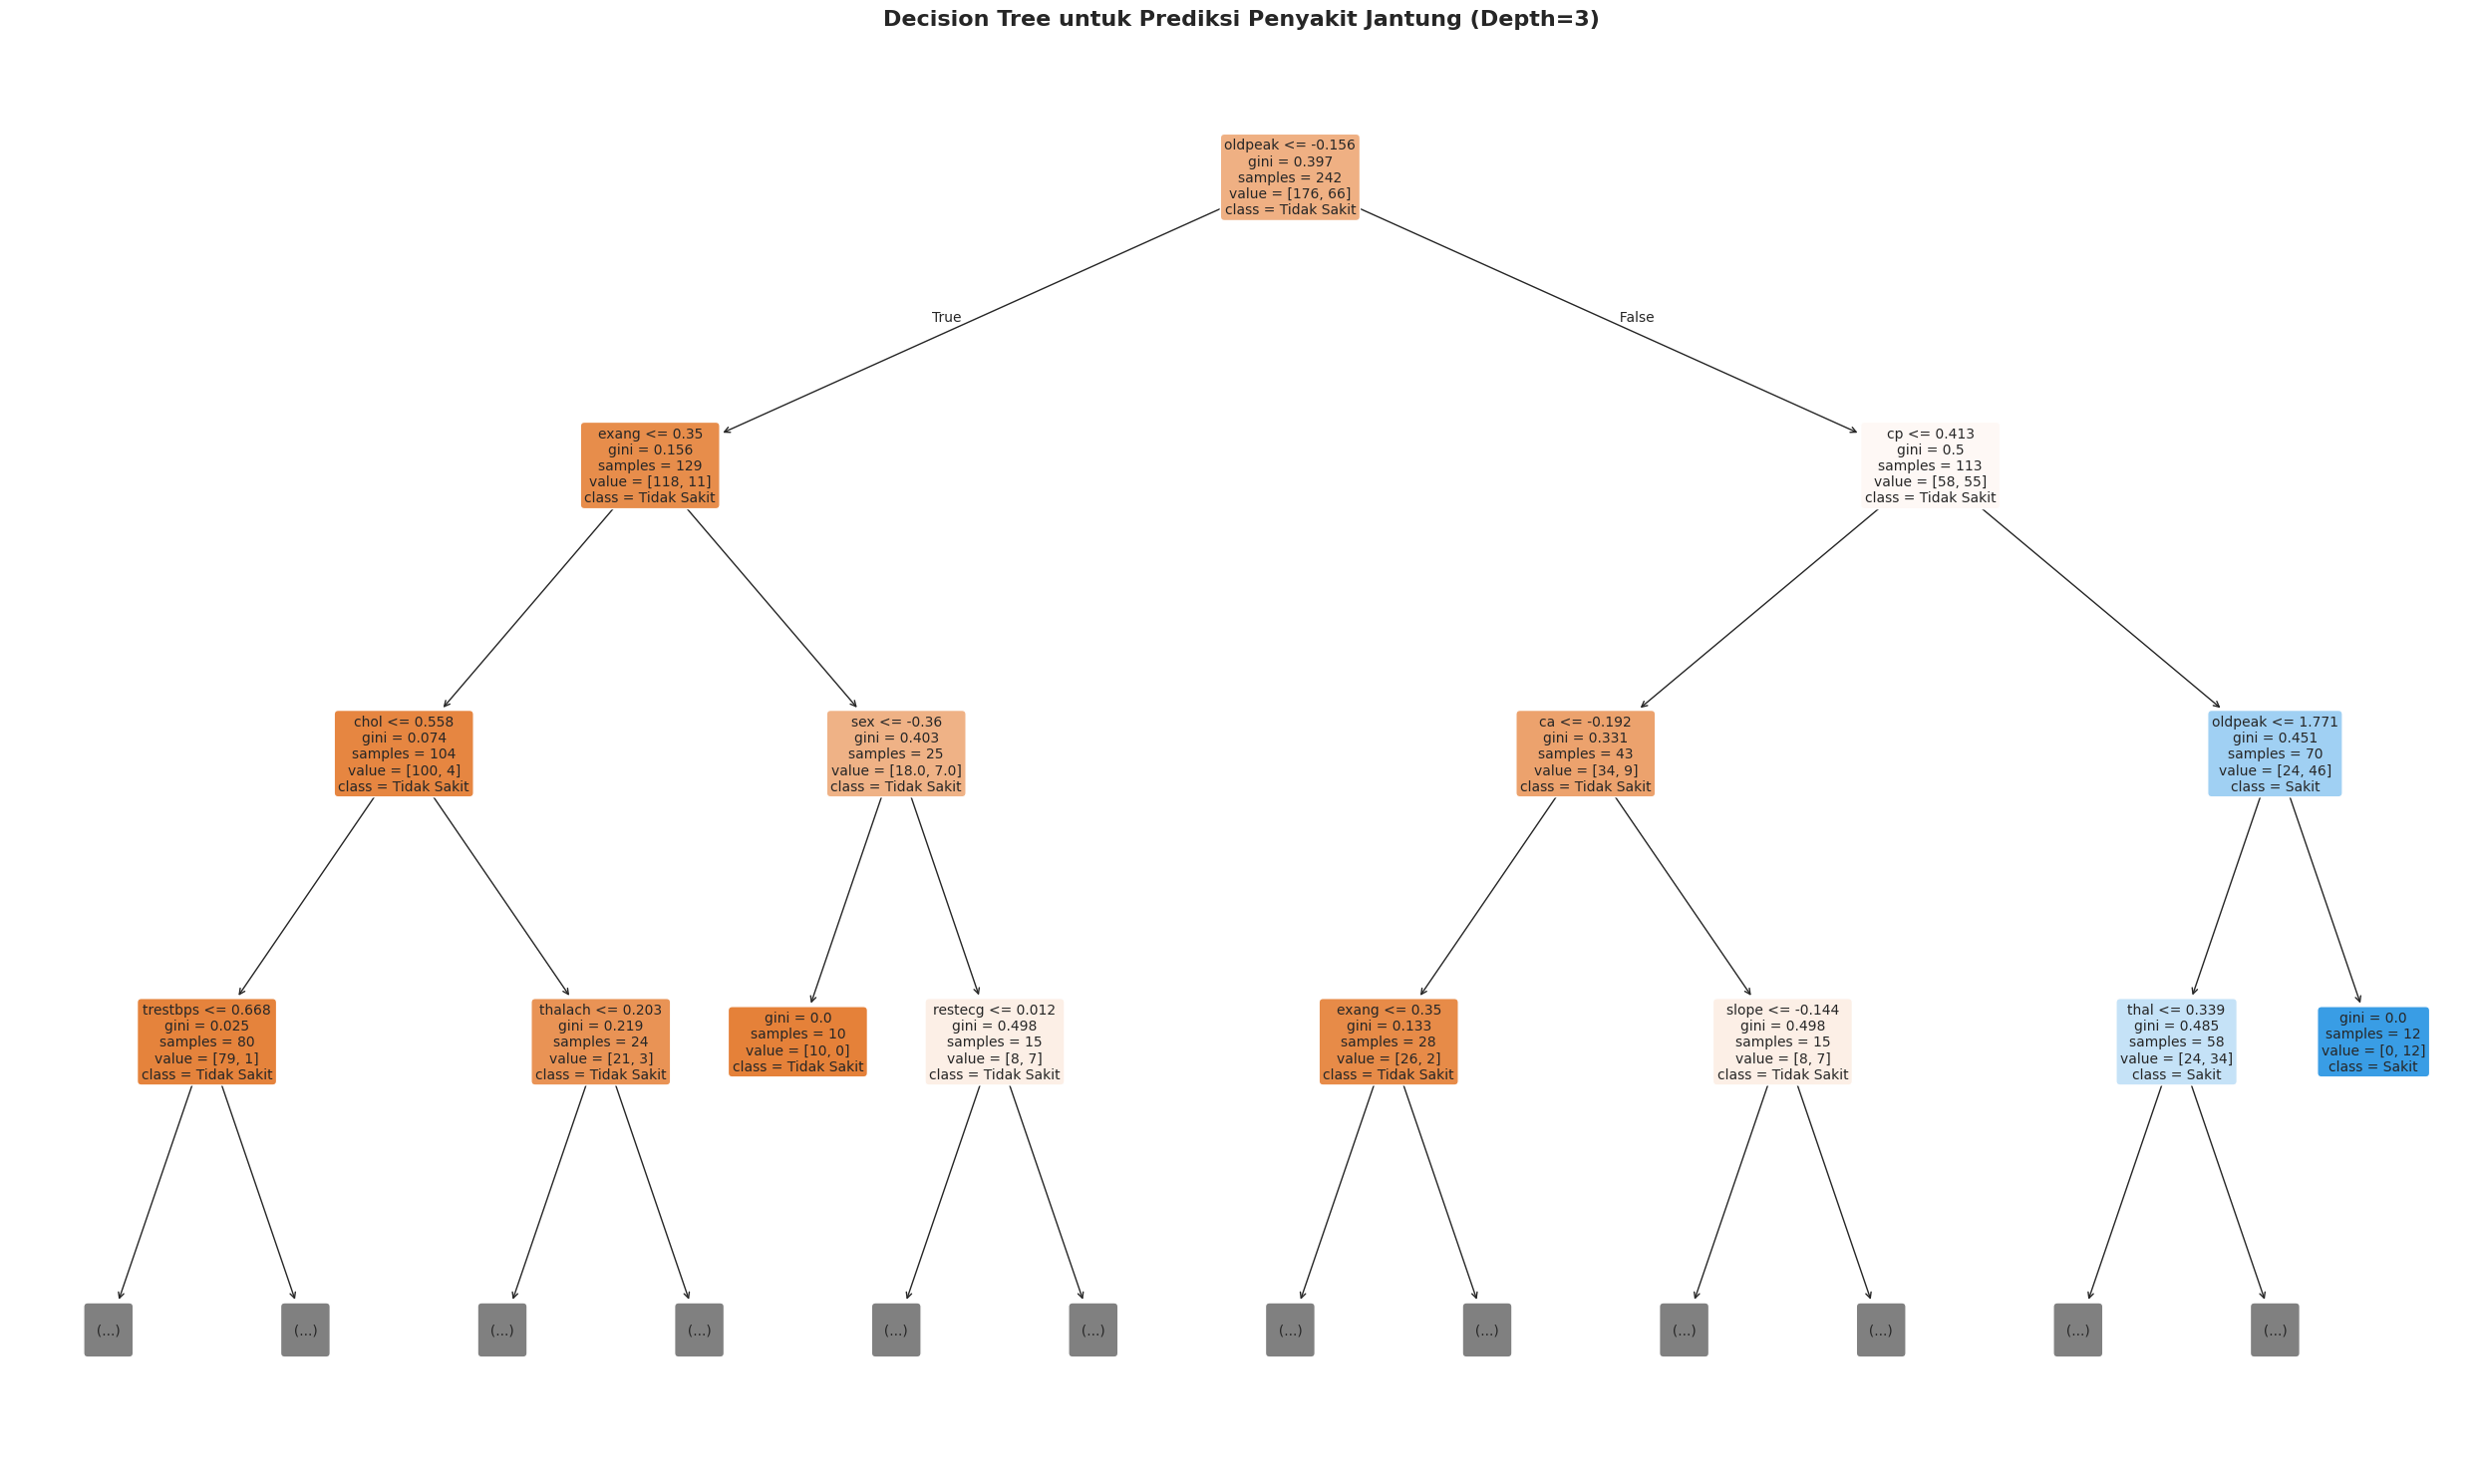

In [ ]:
# 16. Visualisasi Decision Tree
plt.figure(figsize=(25, 15))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['Tidak Sakit', 'Sakit'],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3
)
plt.title('Decision Tree untuk Prediksi Penyakit Jantung (Depth=3)',
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# 17. Insight akhir dan simpan model
print("="*60)
print("INSIGHT DAN KESIMPULAN")
print("="*60)

# Fitur paling penting
top_features = feature_importance.head(5)
print("\n5 Fitur Paling Penting (Decision Tree):")
for idx, row in top_features.iterrows():
    print(f"  • {row['Fitur']}: {row['Importance']:.4f}")

# Rekomendasi
print("\n" + "="*60)
print("REKOMENDASI")
print("="*60)
print("1. Gunakan Decision Tree sebagai model utama karena akurasi tertinggi")
print("2. Fitur paling penting: thalach, cp, oldpeak, ca, exang")
print("3. Untuk pengembangan selanjutnya:")
print("   - Tambahkan lebih banyak data (minimal 1000 sampel)")
print("   - Coba algoritma Random Forest atau XGBoost")
print("   - Implementasikan dalam aplikasi web untuk kemudahan akses")

# Simpan model
joblib.dump(dt_model, 'heart_disease_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("\n✅ Model dan scaler berhasil disimpan!")

# Download model
from google.colab import files
files.download('heart_disease_model.pkl')
files.download('scaler.pkl')
print("\n✅ Model sedang di-download...")

INSIGHT DAN KESIMPULAN

5 Fitur Paling Penting (Decision Tree):
  • oldpeak: 0.3878
  • cp: 0.1866
  • exang: 0.0852
  • thalach: 0.0680
  • slope: 0.0680

REKOMENDASI
1. Gunakan Decision Tree sebagai model utama karena akurasi tertinggi
2. Fitur paling penting: thalach, cp, oldpeak, ca, exang
3. Untuk pengembangan selanjutnya:
   - Tambahkan lebih banyak data (minimal 1000 sampel)
   - Coba algoritma Random Forest atau XGBoost
   - Implementasikan dalam aplikasi web untuk kemudahan akses

✅ Model dan scaler berhasil disimpan!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Model sedang di-download...
